In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import warnings
import pickle
warnings.filterwarnings('ignore')

In [99]:
#Load the data that was transformed in GoDaddy_EDA.ipynb
df_state = pd.read_csv('microbusiness_state_data.csv')
df_county = pd.read_csv('microbusiness_county_data.csv')
df_city = pd.read_csv('microbusiness_city_data.csv')

In [100]:
#Convert Date columns to datetime
df_state['Date'] = pd.to_datetime(df_state['Date'])
df_county['Date'] = pd.to_datetime(df_county['Date'])
df_city['Date'] = pd.to_datetime(df_city['Date'])

## Microbusiness Forecasts at the State Level

In [101]:
df_state.head()

,state_name,state_abbrev,Date,Microbusinesses,Microbusiness Density,state,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,Alaska,AK,2019-08-01,31005.0,4.198284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alabama,AL,2019-08-01,146473.0,3.010948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arkansas,AR,2019-08-01,84119.0,2.812713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arizona,AZ,2019-08-01,566930.0,8.161159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,2019-08-01,3399846.0,8.684428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
df_state_group = df_state[['Date', 'Microbusinesses', 'Microbusiness Density', 'wgtIndex_even', 'wgtIndex_even_engagement', 
                           'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].groupby(['Date']).mean()

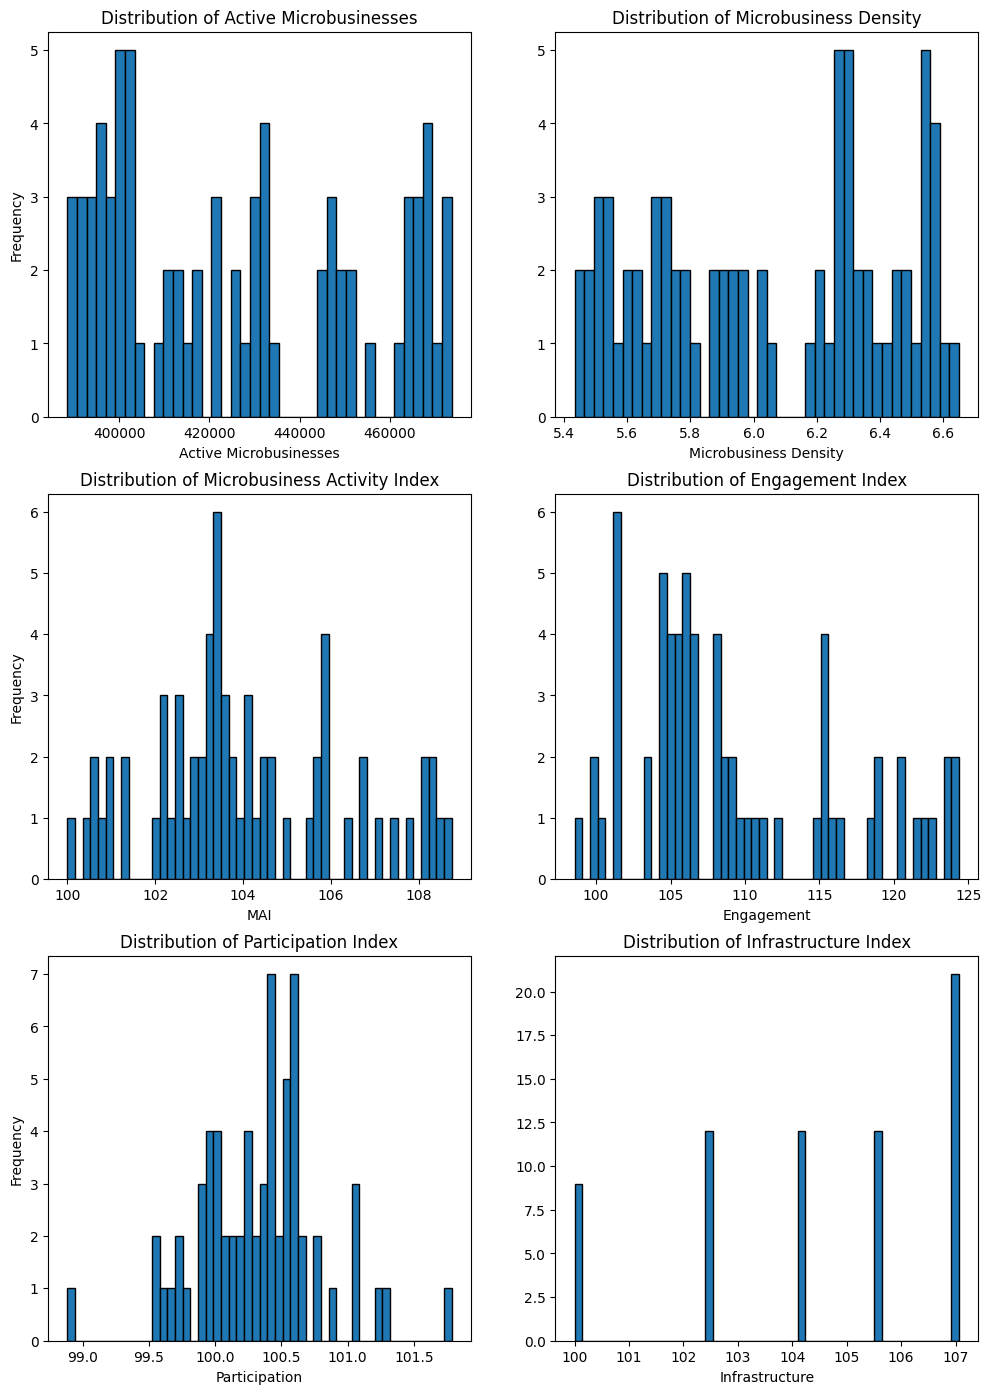

In [103]:
#Histogram of the average of microbusinesses and microbusiness density across the states
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 17))

ax[0, 0].hist(df_state_group['Microbusinesses'], bins = 40, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Active Microbusinesses');
ax[0, 0].set_xlabel('Active Microbusinesses');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_state_group['Microbusiness Density'], bins = 40, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Microbusiness Density');
ax[0, 1].set_xlabel('Microbusiness Density');

ax[1, 0].hist(df_state_group['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Microbusiness Activity Index');
ax[1, 0].set_xlabel('MAI');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_state_group['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Engagement Index');
ax[1, 1].set_xlabel('Engagement');

ax[2, 0].hist(df_state_group['wgtIndex_even_participation'], bins = 50, edgecolor = 'black');
ax[2, 0].set_title('Distribution of Participation Index');
ax[2, 0].set_xlabel('Participation');
ax[2, 0].set_ylabel('Frequency');

ax[2, 1].hist(df_state_group['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[2, 1].set_title('Distribution of Infrastructure Index');
ax[2, 1].set_xlabel('Infrastructure');

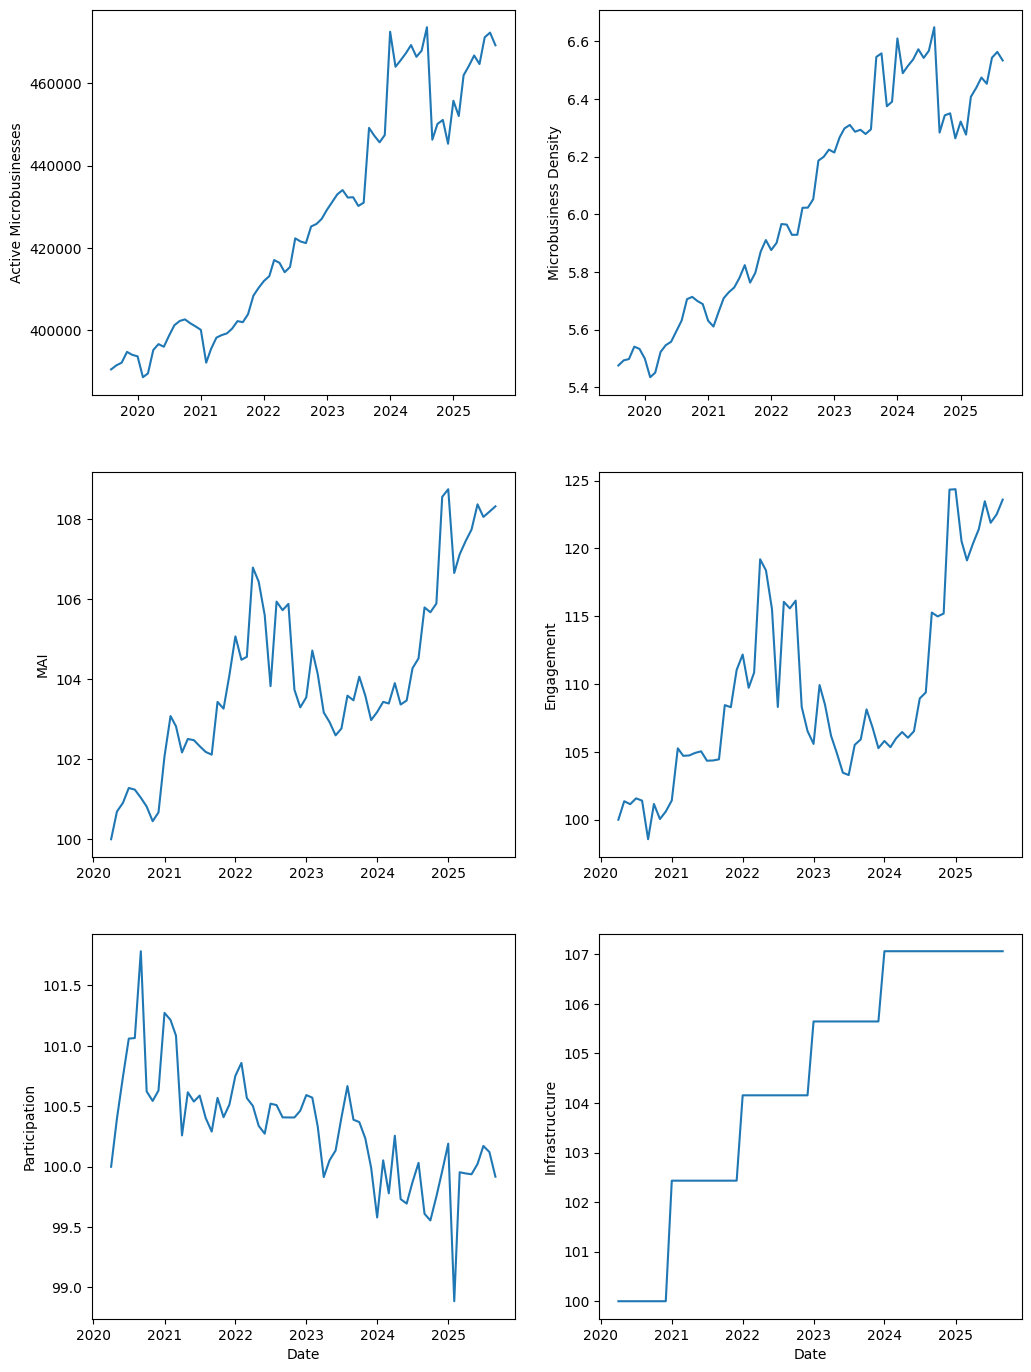

In [104]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 17))

df_micro = df_state_group.copy()
monthly_data = df_micro.resample('MS').sum()

ax[0, 0].plot(monthly_data.index.values, monthly_data['Microbusinesses'].values)
#ax[0, 0].set_title('Microbusiness Activity & Density Over Time');
ax[0, 0].set_ylabel('Active Microbusinesses');

ax[0, 1].plot(monthly_data.index.values, monthly_data['Microbusiness Density'].values)
#ax[0, 1].set_xlabel('Date');
ax[0, 1].set_ylabel('Microbusiness Density');

ax[1, 0].plot(monthly_data.index[monthly_data['wgtIndex_even'] > 0].values, 
              monthly_data['wgtIndex_even'][monthly_data['wgtIndex_even'] > 0].values)
ax[1, 0].set_ylabel('MAI');

ax[1, 1].plot(monthly_data[monthly_data['wgtIndex_even_engagement'] > 0].index.values, 
              monthly_data['wgtIndex_even_engagement'][monthly_data['wgtIndex_even_engagement'] > 0].values)
ax[1, 1].set_ylabel('Engagement');

ax[2, 0].plot(monthly_data.index[monthly_data['wgtIndex_even_participation'] > 0].values, 
              monthly_data['wgtIndex_even_participation'][monthly_data['wgtIndex_even_participation'] > 0].values)
ax[2, 0].set_xlabel('Date');
ax[2, 0].set_ylabel('Participation');

ax[2, 1].plot(monthly_data.index[monthly_data['wgtIndex_even_infrastructure'] > 0].values, 
              monthly_data['wgtIndex_even_infrastructure'][monthly_data['wgtIndex_even_infrastructure'] > 0].values)
ax[2, 1].set_xlabel('Date');
ax[2, 1].set_ylabel('Infrastructure');

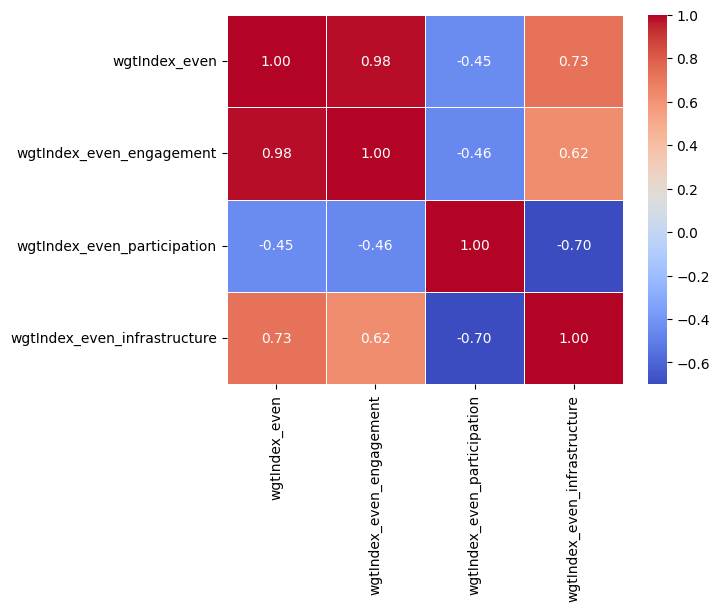

In [105]:
sns.heatmap(data = df_state_group[['wgtIndex_even', 'wgtIndex_even_engagement', 'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].corr(), 
            annot = True, fmt = '.2f', linewidths=.5, cmap = "coolwarm");

### Forecast of Active Microbusinesses

Prophet Approach with No Independent Variables

In [106]:
micro_state_prophet = pd.DataFrame(df_state_group['Microbusinesses'])
micro_state_prophet.reset_index(inplace = True)
micro_state_prophet.rename(columns = {'Date':'ds', 'Microbusinesses':'y'}, inplace = True)

proph = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

prophet_fit = proph.fit(micro_state_prophet)

18:19:24 - cmdstanpy - INFO - Chain [1] start processing


18:19:29 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
y_hat_prophet = prophet_fit.predict(pd.DataFrame(micro_state_prophet['ds']))
y_hat_proph = y_hat_prophet[['ds', 'yhat']]
y_hat_prophet = y_hat_proph['yhat']
y_hat_prophet[y_hat_prophet < 0] = 0

mask = ~np.isnan(df_state_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet)

mse_prophet = mean_squared_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
rmse_prophet = mse_prophet**(1/2)
mae_prophet = mean_absolute_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
mape_prophet = mean_absolute_percentage_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
r2_prophet = r2_score(df_state_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
[mse_prophet, rmse_prophet, mae_prophet, mape_prophet, r2_prophet]

[3280525.720139583,
 1811.2221620054186,
 1410.20406916117,
 0.0032991992249664904,
 0.995711601063519]

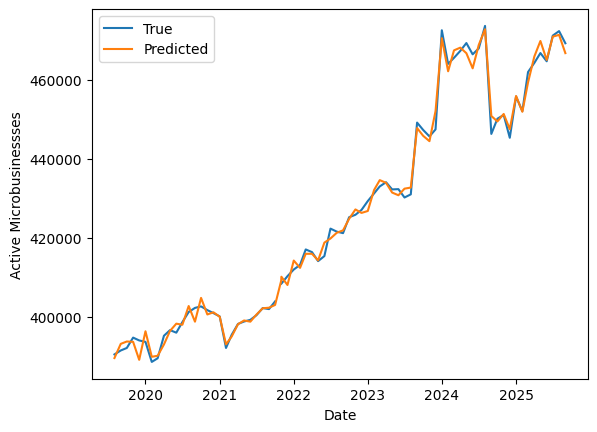

In [108]:
plt.plot(df_state_group.index.values, df_state_group['Microbusinesses'].values)
plt.plot(df_state_group.index.values, y_hat_prophet.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

In [197]:
#Save date column
micro_state_prophet['ds'].to_csv('dates.csv', index = False)

Prophet Approach with MAI as an Independent Variable

In [109]:
micro_state_prophet2 = df_state_group[['Microbusinesses', 'wgtIndex_even']]
micro_state_prophet2.reset_index(inplace = True)
micro_state_prophet2.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even':'x1'}, inplace = True)

micro_state_prophet2['x1'] = micro_state_prophet2['x1'].fillna(micro_state_prophet2['x1'].median())

proph2 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph2.add_regressor('x1')
prophet_fit2 = proph2.fit(micro_state_prophet2)

18:19:39 - cmdstanpy - INFO - Chain [1] start processing


18:19:46 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
y_hat_prophet2 = prophet_fit2.predict(pd.DataFrame(micro_state_prophet2[['ds', 'x1']]))
y_hat_proph2 = y_hat_prophet2[['ds', 'yhat']]
y_hat_prophet2 = y_hat_proph2['yhat']
y_hat_prophet2[y_hat_prophet2 < 0] = 0

mask = ~np.isnan(df_state_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet2)

mse_prophet2 = mean_squared_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
rmse_prophet2 = mse_prophet2**(1/2)
mae_prophet2 = mean_absolute_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
mape_prophet2 = mean_absolute_percentage_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
r2_prophet2 = r2_score(df_state_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
[mse_prophet2, rmse_prophet2, mae_prophet2, mape_prophet2, r2_prophet2]

[2236547.841270322,
 1495.5092247359498,
 1169.3854659472677,
 0.0027499066147544486,
 0.9970763194066699]

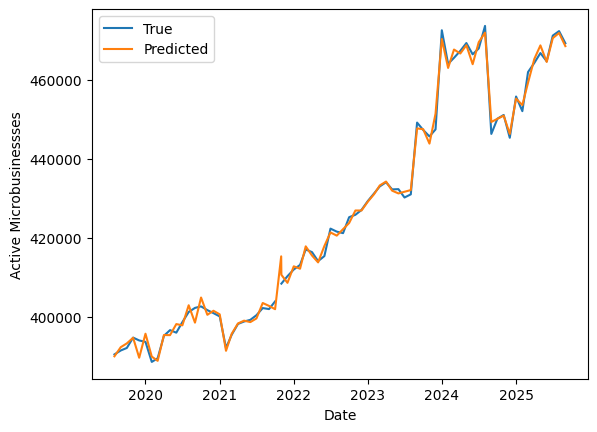

In [111]:
plt.plot(df_state_group.index.values, df_state_group['Microbusinesses'].values)
plt.plot(df_state_group.index.values, y_hat_prophet2.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Infrastructure Index as an Independent Variable

In [112]:
micro_state_prophet3 = df_state_group[['Microbusinesses', 'wgtIndex_even_infrastructure']]
micro_state_prophet3.reset_index(inplace = True)
micro_state_prophet3.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even_infrastructure':'x1'}, inplace = True)

micro_state_prophet3['x1'] = micro_state_prophet3['x1'].fillna(micro_state_prophet3['x1'].median())

proph3 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph3.add_regressor('x1')
prophet_fit3 = proph3.fit(micro_state_prophet3)

18:19:54 - cmdstanpy - INFO - Chain [1] start processing


18:20:01 - cmdstanpy - INFO - Chain [1] done processing


In [113]:
y_hat_prophet3 = prophet_fit3.predict(pd.DataFrame(micro_state_prophet3[['ds', 'x1']]))
y_hat_proph3 = y_hat_prophet3[['ds', 'yhat']]
y_hat_prophet3 = y_hat_proph3['yhat']
y_hat_prophet3[y_hat_prophet3 < 0] = 0

mask = ~np.isnan(df_state_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet3)

mse_prophet3 = mean_squared_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
rmse_prophet3 = mse_prophet3**(1/2)
mae_prophet3 = mean_absolute_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
mape_prophet3 = mean_absolute_percentage_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
r2_prophet3 = r2_score(df_state_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
[mse_prophet3, rmse_prophet3, mae_prophet3, mape_prophet3, r2_prophet3]

[3280378.6387189743,
 1811.1815587397566,
 1408.729629121023,
 0.0032960111399829945,
 0.9957117933326434]

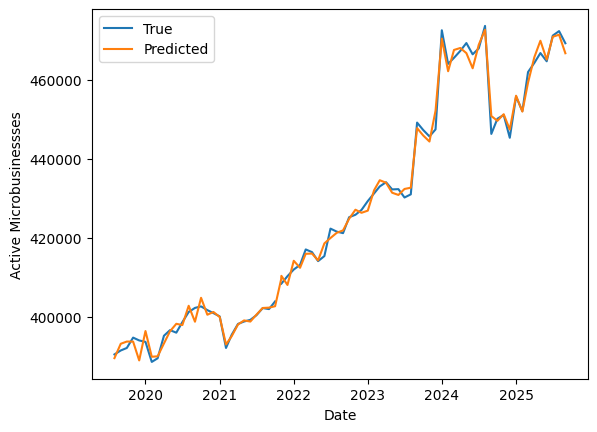

In [114]:
plt.plot(df_state_group.index.values, df_state_group['Microbusinesses'].values)
plt.plot(df_state_group.index.values, y_hat_prophet3.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Engagement Index as an Independent Variable

In [115]:
micro_state_prophet4 = df_state_group[['Microbusinesses', 'wgtIndex_even_engagement']]
micro_state_prophet4.reset_index(inplace = True)
micro_state_prophet4.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even_engagement':'x1'}, inplace = True)

micro_state_prophet4['x1'] = micro_state_prophet4['x1'].fillna(micro_state_prophet4['x1'].median())

proph4 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph4.add_regressor('x1')
prophet_fit4 = proph4.fit(micro_state_prophet4)

18:20:03 - cmdstanpy - INFO - Chain [1] start processing


18:20:11 - cmdstanpy - INFO - Chain [1] done processing


In [116]:
y_hat_prophet4 = prophet_fit4.predict(pd.DataFrame(micro_state_prophet4[['ds', 'x1']]))
y_hat_proph4 = y_hat_prophet4[['ds', 'yhat']]
y_hat_prophet4 = y_hat_proph4['yhat']
y_hat_prophet4[y_hat_prophet4 < 0] = 0

mask = ~np.isnan(df_state_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet4)

mse_prophet4 = mean_squared_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
rmse_prophet4 = mse_prophet4**(1/2)
mae_prophet4 = mean_absolute_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
mape_prophet4 = mean_absolute_percentage_error(df_state_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
r2_prophet4 = r2_score(df_state_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
[mse_prophet4, rmse_prophet4, mae_prophet4, mape_prophet4, r2_prophet4]

[1538889.8094077073,
 1240.5199754166424,
 1011.6909290583422,
 0.002385822460360183,
 0.9979883183413222]

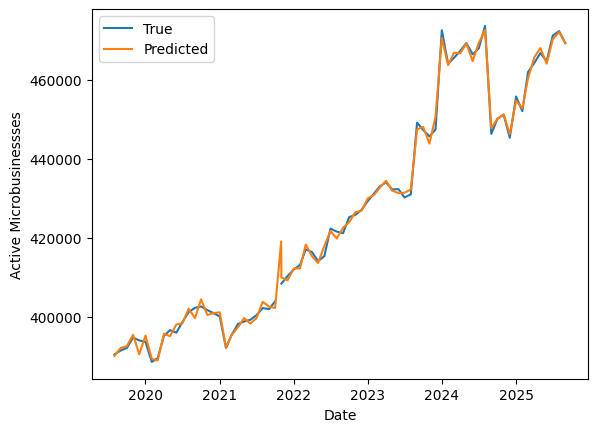

In [117]:
plt.plot(df_state_group.index.values, df_state_group['Microbusinesses'].values)
plt.plot(df_state_group.index.values, y_hat_prophet4.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

In [22]:
#Save the Prophet model with the engagement index as an independent variable
with open('active_microbusinesses_state_level_model.pkl', 'wb') as f:
    pickle.dump(proph4, f)

In [119]:
#Save the independent variable
np.save('engagement_index_state.npy', micro_state_prophet4['x1'])

### Forecast of Microbusiness Density

Prophet Approach with No Independent Variables

In [120]:
micro_state_prophet = pd.DataFrame(df_state_group['Microbusiness Density'])
micro_state_prophet.reset_index(inplace = True)
micro_state_prophet.rename(columns = {'Date':'ds', 'Microbusiness Density':'y'}, inplace = True)

proph = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

prophet_fit = proph.fit(micro_state_prophet)

18:21:39 - cmdstanpy - INFO - Chain [1] start processing
18:21:45 - cmdstanpy - INFO - Chain [1] done processing


In [121]:
y_hat_prophet = prophet_fit.predict(pd.DataFrame(micro_state_prophet['ds']))
y_hat_proph = y_hat_prophet[['ds', 'yhat']]
y_hat_prophet = y_hat_proph['yhat']
y_hat_prophet[y_hat_prophet < 0] = 0

mask = ~np.isnan(df_state_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet)

mse_prophet = mean_squared_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
rmse_prophet = mse_prophet**(1/2)
mae_prophet = mean_absolute_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
mape_prophet = mean_absolute_percentage_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
r2_prophet = r2_score(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
[mse_prophet, rmse_prophet, mae_prophet, mape_prophet, r2_prophet]

[0.000609171512109132,
 0.024681400124570162,
 0.01922176834643016,
 0.0031755572548844,
 0.9957109169016416]

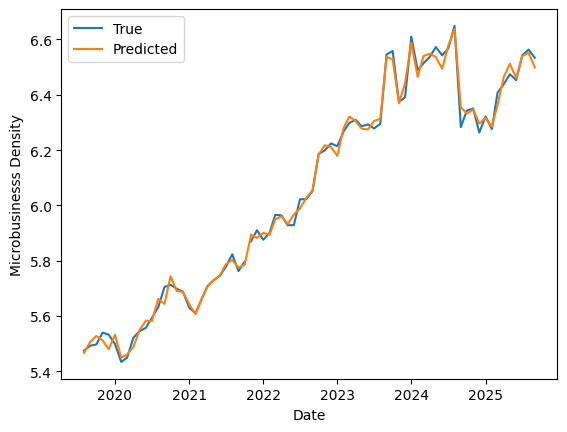

In [122]:
plt.plot(df_state_group.index.values, df_state_group['Microbusiness Density'].values)
plt.plot(df_state_group.index.values, y_hat_prophet.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with MAI as an Independent Variable

In [123]:
micro_state_prophet2 = df_state_group[['Microbusiness Density', 'wgtIndex_even']]
micro_state_prophet2.reset_index(inplace = True)
micro_state_prophet2.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even':'x1'}, inplace = True)

micro_state_prophet2['x1'] = micro_state_prophet2['x1'].fillna(micro_state_prophet2['x1'].median())

proph2 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph2.add_regressor('x1')
prophet_fit2 = proph2.fit(micro_state_prophet2)

18:21:47 - cmdstanpy - INFO - Chain [1] start processing


18:21:53 - cmdstanpy - INFO - Chain [1] done processing


In [124]:
y_hat_prophet2 = prophet_fit2.predict(pd.DataFrame(micro_state_prophet2[['ds', 'x1']]))
y_hat_proph2 = y_hat_prophet2[['ds', 'yhat']]
y_hat_prophet2 = y_hat_proph2['yhat']
y_hat_prophet2[y_hat_prophet2 < 0] = 0

mask = ~np.isnan(df_state_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet2)

mse_prophet2 = mean_squared_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
rmse_prophet2 = mse_prophet2**(1/2)
mae_prophet2 = mean_absolute_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
mape_prophet2 = mean_absolute_percentage_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
r2_prophet2 = r2_score(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
[mse_prophet2, rmse_prophet2, mae_prophet2, mape_prophet2, r2_prophet2]

[0.00040839301217942934,
 0.020208736036165877,
 0.015323884034711284,
 0.0025433401156617105,
 0.9971245674966615]

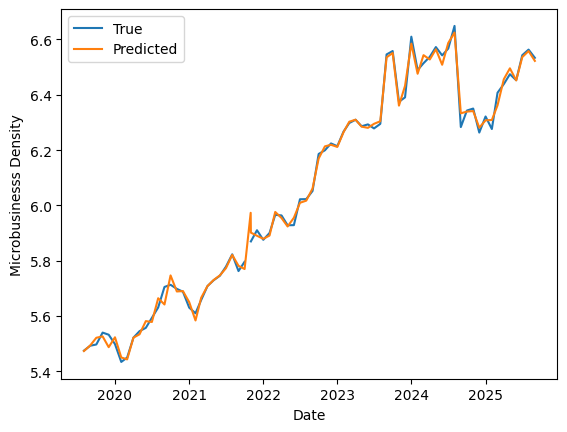

In [125]:
plt.plot(df_state_group.index.values, df_state_group['Microbusiness Density'].values)
plt.plot(df_state_group.index.values, y_hat_prophet2.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Infrastructure Index as an Independent Variable

In [126]:
micro_state_prophet3 = df_state_group[['Microbusiness Density', 'wgtIndex_even_infrastructure']]
micro_state_prophet3.reset_index(inplace = True)
micro_state_prophet3.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even_infrastructure':'x1'}, inplace = True)

micro_state_prophet3['x1'] = micro_state_prophet3['x1'].fillna(micro_state_prophet3['x1'].median())

proph3 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph3.add_regressor('x1')
prophet_fit3 = proph3.fit(micro_state_prophet3)

18:21:59 - cmdstanpy - INFO - Chain [1] start processing
18:22:05 - cmdstanpy - INFO - Chain [1] done processing


In [127]:
y_hat_prophet3 = prophet_fit3.predict(pd.DataFrame(micro_state_prophet3[['ds', 'x1']]))
y_hat_proph3 = y_hat_prophet3[['ds', 'yhat']]
y_hat_prophet3 = y_hat_proph3['yhat']
y_hat_prophet3[y_hat_prophet3 < 0] = 0

mask = ~np.isnan(df_state_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet3)

mse_prophet3 = mean_squared_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
rmse_prophet3 = mse_prophet3**(1/2)
mae_prophet3 = mean_absolute_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
mape_prophet3 = mean_absolute_percentage_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
r2_prophet3 = r2_score(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
[mse_prophet3, rmse_prophet3, mae_prophet3, mape_prophet3, r2_prophet3]

[0.0006083064198748765,
 0.02466386871265083,
 0.019171900385303278,
 0.003166686672715179,
 0.9957170078832563]

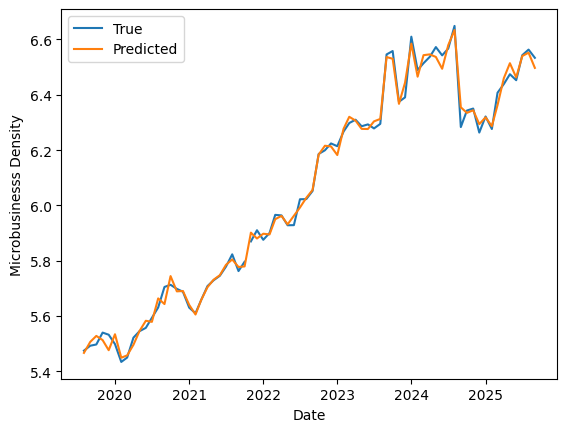

In [128]:
plt.plot(df_state_group.index.values, df_state_group['Microbusiness Density'].values)
plt.plot(df_state_group.index.values, y_hat_prophet3.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Engagement Index as an Independent Variable

In [129]:
micro_state_prophet4 = df_state_group[['Microbusiness Density', 'wgtIndex_even_engagement']]
micro_state_prophet4.reset_index(inplace = True)
micro_state_prophet4.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even_engagement':'x1'}, inplace = True)

micro_state_prophet4['x1'] = micro_state_prophet4['x1'].fillna(micro_state_prophet4['x1'].median())

proph4 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph4.add_regressor('x1')
prophet_fit4 = proph4.fit(micro_state_prophet4)

18:22:10 - cmdstanpy - INFO - Chain [1] start processing
18:22:16 - cmdstanpy - INFO - Chain [1] done processing


In [130]:
y_hat_prophet4 = prophet_fit4.predict(pd.DataFrame(micro_state_prophet4[['ds', 'x1']]))
y_hat_proph4 = y_hat_prophet4[['ds', 'yhat']]
y_hat_prophet4 = y_hat_proph4['yhat']
y_hat_prophet4[y_hat_prophet4 < 0] = 0

mask = ~np.isnan(df_state_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet4)

mse_prophet4 = mean_squared_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
rmse_prophet4 = mse_prophet4**(1/2)
mae_prophet4 = mean_absolute_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
mape_prophet4 = mean_absolute_percentage_error(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
r2_prophet4 = r2_score(df_state_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
[mse_prophet4, rmse_prophet4, mae_prophet4, mape_prophet4, r2_prophet4]

[0.00025199162999879567,
 0.015874244233940578,
 0.012926583849289118,
 0.002151382150301369,
 0.9982257656182681]

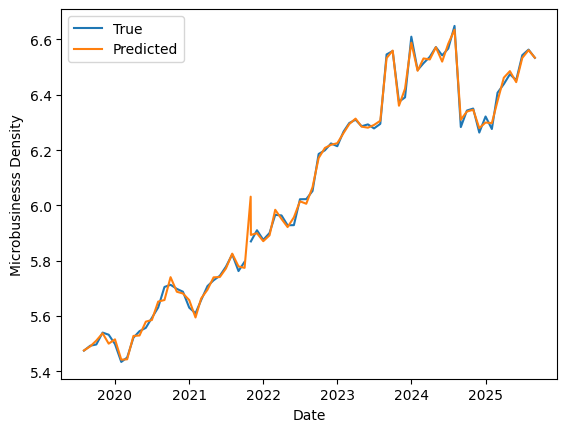

In [131]:
plt.plot(df_state_group.index.values, df_state_group['Microbusiness Density'].values)
plt.plot(df_state_group.index.values, y_hat_prophet4.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

In [35]:
#Save the Prophet model with the engagement index as an independent variable
with open('microbusiness_density_state_level_model.pkl', 'wb') as f:
    pickle.dump(proph4, f)

In [132]:
#Save the independent variable
np.save('engagement_index_state.npy', micro_state_prophet4['x1'])

## Microbusiness Forecasts at the County Level

In [135]:
df_county.head()

,cfips,county,Date,Microbusinesses,Microbusiness Density,county_id,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,1001.0,"Autauga County, AL",2019-08-01,1249.0,2.985824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1003.0,"Baldwin County, AL",2019-08-01,11464.0,7.057810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1005.0,"Barbour County, AL",2019-08-01,222.0,1.091124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1007.0,"Bibb County, AL",2019-08-01,234.0,1.309604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1009.0,"Blount County, AL",2019-08-01,681.0,1.541526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
df_county_group = df_county[['Date', 'Microbusinesses', 'Microbusiness Density', 'wgtIndex_even', 'wgtIndex_even_engagement', 
                           'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].groupby(['Date']).mean()

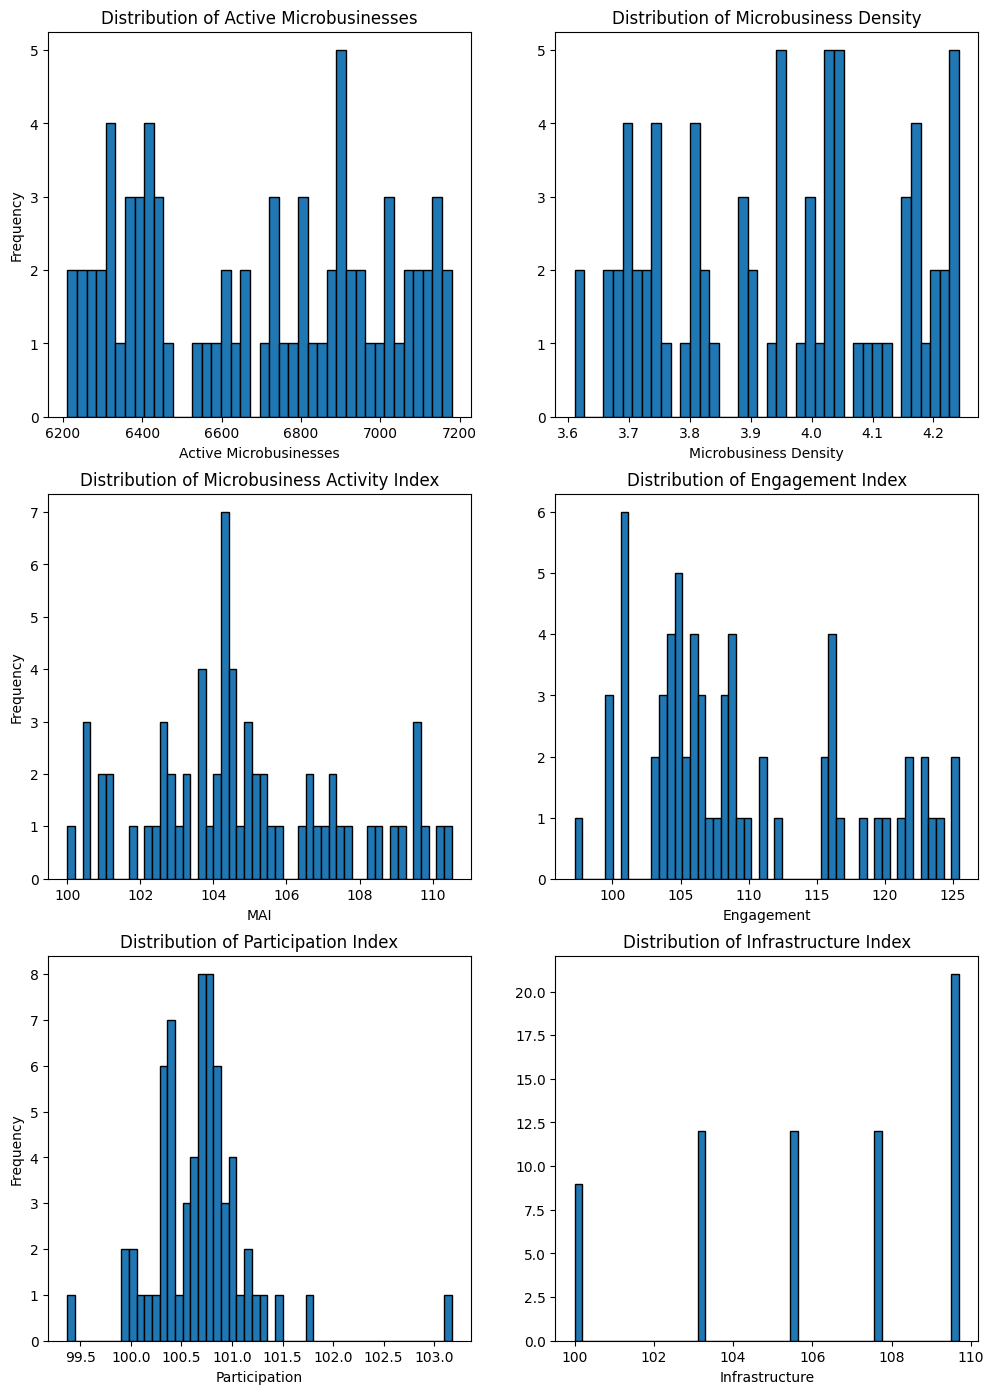

In [137]:
#Histogram of the average of microbusinesses and microbusiness density across counties
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 17))

ax[0, 0].hist(df_county_group['Microbusinesses'], bins = 40, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Active Microbusinesses');
ax[0, 0].set_xlabel('Active Microbusinesses');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_county_group['Microbusiness Density'], bins = 40, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Microbusiness Density');
ax[0, 1].set_xlabel('Microbusiness Density');

ax[1, 0].hist(df_county_group['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Microbusiness Activity Index');
ax[1, 0].set_xlabel('MAI');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_county_group['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Engagement Index');
ax[1, 1].set_xlabel('Engagement');

ax[2, 0].hist(df_county_group['wgtIndex_even_participation'], bins = 50, edgecolor = 'black');
ax[2, 0].set_title('Distribution of Participation Index');
ax[2, 0].set_xlabel('Participation');
ax[2, 0].set_ylabel('Frequency');

ax[2, 1].hist(df_county_group['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[2, 1].set_title('Distribution of Infrastructure Index');
ax[2, 1].set_xlabel('Infrastructure');

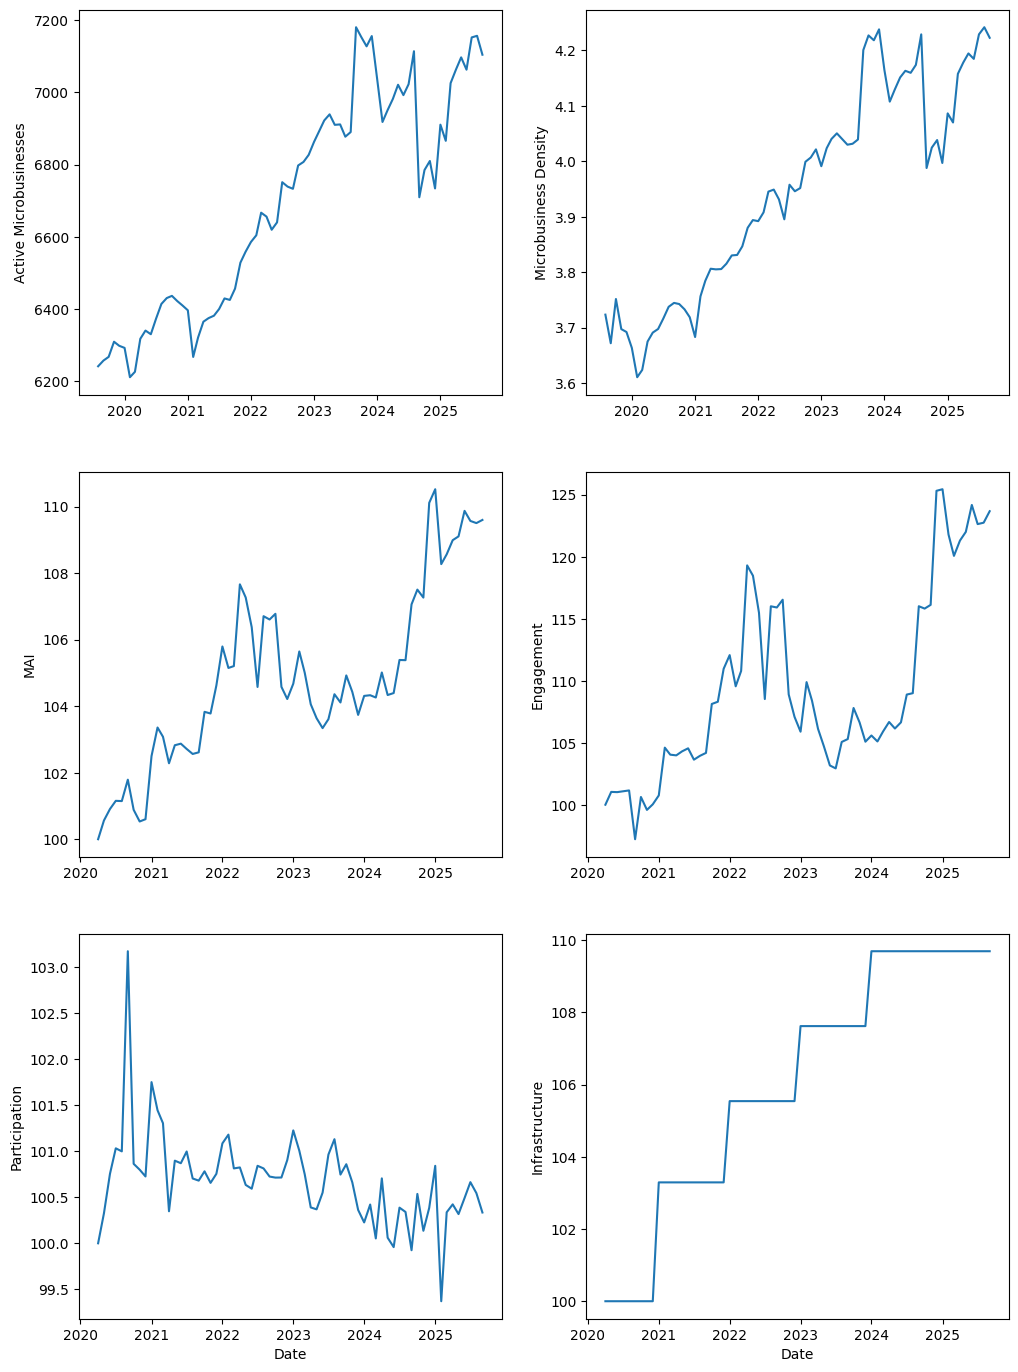

In [138]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 17))

df_micro = df_county_group.copy()
monthly_data = df_micro.resample('MS').sum()

ax[0, 0].plot(monthly_data.index.values, monthly_data['Microbusinesses'].values)
#ax[0, 0].set_title('Microbusiness Activity & Density Over Time');
ax[0, 0].set_ylabel('Active Microbusinesses');

ax[0, 1].plot(monthly_data.index.values, monthly_data['Microbusiness Density'].values)
#ax[0, 1].set_xlabel('Date');
ax[0, 1].set_ylabel('Microbusiness Density');

ax[1, 0].plot(monthly_data.index[monthly_data['wgtIndex_even'] > 0].values, 
              monthly_data['wgtIndex_even'][monthly_data['wgtIndex_even'] > 0].values)
ax[1, 0].set_ylabel('MAI');

ax[1, 1].plot(monthly_data[monthly_data['wgtIndex_even_engagement'] > 0].index.values, 
              monthly_data['wgtIndex_even_engagement'][monthly_data['wgtIndex_even_engagement'] > 0].values)
ax[1, 1].set_ylabel('Engagement');

ax[2, 0].plot(monthly_data.index[monthly_data['wgtIndex_even_participation'] > 0].values, 
              monthly_data['wgtIndex_even_participation'][monthly_data['wgtIndex_even_participation'] > 0].values)
ax[2, 0].set_xlabel('Date');
ax[2, 0].set_ylabel('Participation');

ax[2, 1].plot(monthly_data.index[monthly_data['wgtIndex_even_infrastructure'] > 0].values, 
              monthly_data['wgtIndex_even_infrastructure'][monthly_data['wgtIndex_even_infrastructure'] > 0].values)
ax[2, 1].set_xlabel('Date');
ax[2, 1].set_ylabel('Infrastructure');

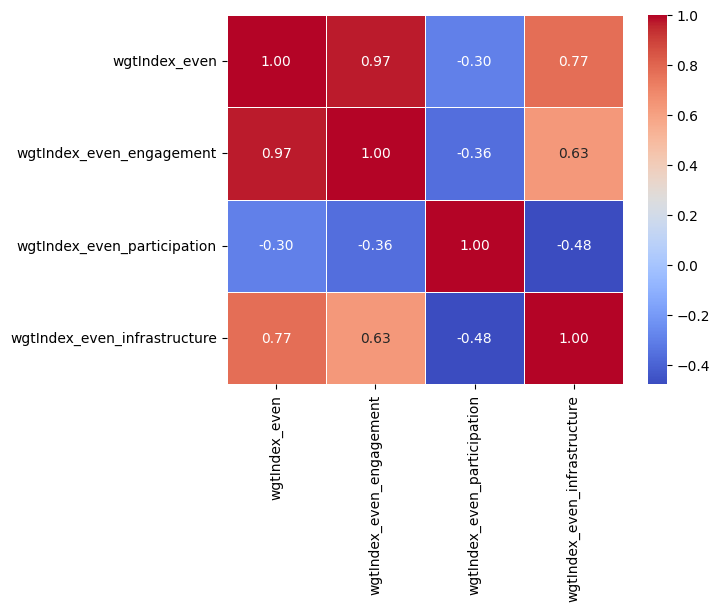

In [139]:
sns.heatmap(data = df_county_group[['wgtIndex_even', 'wgtIndex_even_engagement', 'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].corr(), 
            annot = True, fmt = '.2f', linewidths=.5, cmap = "coolwarm");

### Forecast of Active Microbusinesses

Prophet Approach with No Independent Variables

In [140]:
micro_county_prophet = pd.DataFrame(df_county_group['Microbusinesses'])
micro_county_prophet.reset_index(inplace = True)
micro_county_prophet.rename(columns = {'Date':'ds', 'Microbusinesses':'y'}, inplace = True)

proph = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

prophet_fit = proph.fit(micro_county_prophet)

18:46:08 - cmdstanpy - INFO - Chain [1] start processing


18:46:13 - cmdstanpy - INFO - Chain [1] done processing


In [141]:
y_hat_prophet = prophet_fit.predict(pd.DataFrame(micro_county_prophet['ds']))
y_hat_proph = y_hat_prophet[['ds', 'yhat']]
y_hat_prophet = y_hat_proph['yhat']
y_hat_prophet[y_hat_prophet < 0] = 0

mask = ~np.isnan(df_county_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet)

mse_prophet = mean_squared_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
rmse_prophet = mse_prophet**(1/2)
mae_prophet = mean_absolute_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
mape_prophet = mean_absolute_percentage_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
r2_prophet = r2_score(df_county_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
[mse_prophet, rmse_prophet, mae_prophet, mape_prophet, r2_prophet]

[517.388422778955,
 22.7461738052569,
 18.07221290485383,
 0.0026895042368419173,
 0.9942961180849056]

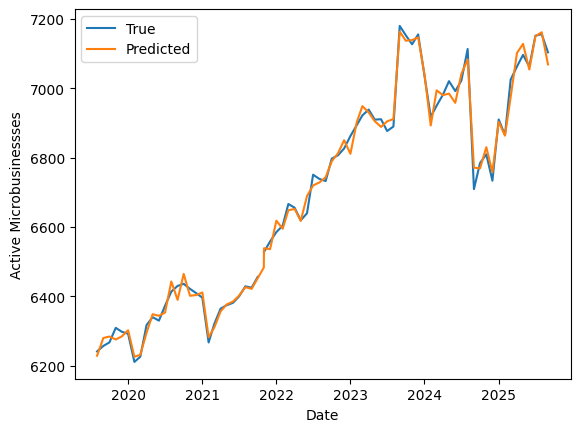

In [142]:
plt.plot(df_county_group.index.values, df_county_group['Microbusinesses'].values)
plt.plot(df_county_group.index.values, y_hat_prophet.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with MAI as an Independent Variable

In [143]:
micro_county_prophet2 = df_county_group[['Microbusinesses', 'wgtIndex_even']]
micro_county_prophet2.reset_index(inplace = True)
micro_county_prophet2.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even':'x1'}, inplace = True)

micro_county_prophet2['x1'] = micro_county_prophet2['x1'].fillna(micro_county_prophet2['x1'].median())

proph2 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph2.add_regressor('x1')
prophet_fit2 = proph2.fit(micro_county_prophet2)

18:46:33 - cmdstanpy - INFO - Chain [1] start processing


18:46:38 - cmdstanpy - INFO - Chain [1] done processing


In [144]:
y_hat_prophet2 = prophet_fit2.predict(pd.DataFrame(micro_county_prophet2[['ds', 'x1']]))
y_hat_proph2 = y_hat_prophet2[['ds', 'yhat']]
y_hat_prophet2 = y_hat_proph2['yhat']
y_hat_prophet2[y_hat_prophet2 < 0] = 0

mask = ~np.isnan(df_county_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet2)

mse_prophet2 = mean_squared_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
rmse_prophet2 = mse_prophet2**(1/2)
mae_prophet2 = mean_absolute_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
mape_prophet2 = mean_absolute_percentage_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
r2_prophet2 = r2_score(df_county_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
[mse_prophet2, rmse_prophet2, mae_prophet2, mape_prophet2, r2_prophet2]

[385.0995993194417,
 19.62395473189443,
 15.379589667972251,
 0.002290329791465847,
 0.9957545191516457]

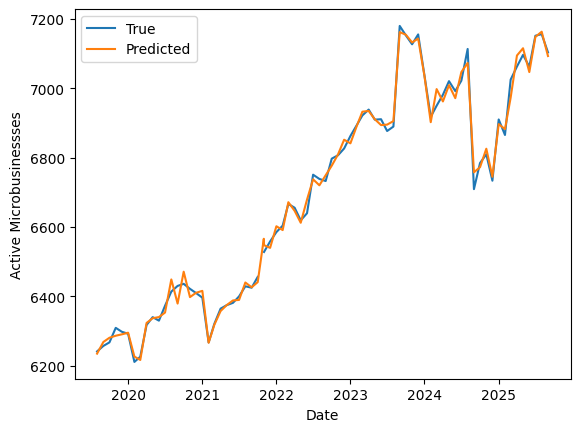

In [145]:
plt.plot(df_county_group.index.values, df_county_group['Microbusinesses'].values)
plt.plot(df_county_group.index.values, y_hat_prophet2.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Infrastructure Index as an Independent Variable

In [146]:
micro_county_prophet3 = df_county_group[['Microbusinesses', 'wgtIndex_even_infrastructure']]
micro_county_prophet3.reset_index(inplace = True)
micro_county_prophet3.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even_infrastructure':'x1'}, inplace = True)

micro_county_prophet3['x1'] = micro_county_prophet3['x1'].fillna(micro_county_prophet3['x1'].median())

proph3 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph3.add_regressor('x1')
prophet_fit3 = proph3.fit(micro_county_prophet3)

18:46:45 - cmdstanpy - INFO - Chain [1] start processing


18:46:51 - cmdstanpy - INFO - Chain [1] done processing


In [147]:
y_hat_prophet3 = prophet_fit3.predict(pd.DataFrame(micro_county_prophet3[['ds', 'x1']]))
y_hat_proph3 = y_hat_prophet3[['ds', 'yhat']]
y_hat_prophet3 = y_hat_proph3['yhat']
y_hat_prophet3[y_hat_prophet3 < 0] = 0

mask = ~np.isnan(df_county_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet3)

mse_prophet3 = mean_squared_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
rmse_prophet3 = mse_prophet3**(1/2)
mae_prophet3 = mean_absolute_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
mape_prophet3 = mean_absolute_percentage_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
r2_prophet3 = r2_score(df_county_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
[mse_prophet3, rmse_prophet3, mae_prophet3, mape_prophet3, r2_prophet3]

[495.3285013838975,
 22.255976756455727,
 17.233739722288426,
 0.002566418018724002,
 0.9945393148422235]

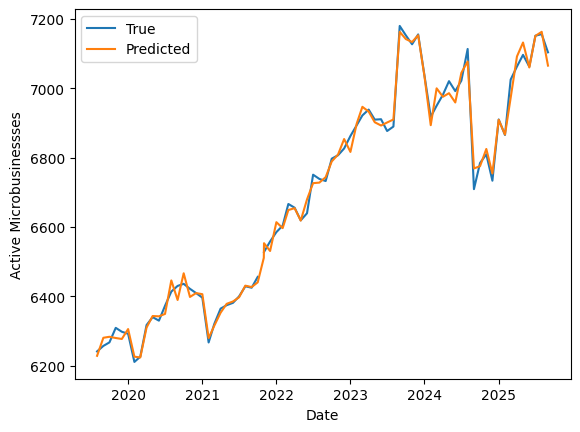

In [148]:
plt.plot(df_county_group.index.values, df_county_group['Microbusinesses'].values)
plt.plot(df_county_group.index.values, y_hat_prophet3.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Engagement Index as an Independent Variable

In [149]:
micro_county_prophet4 = df_county_group[['Microbusinesses', 'wgtIndex_even_engagement']]
micro_county_prophet4.reset_index(inplace = True)
micro_county_prophet4.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even_engagement':'x1'}, inplace = True)

micro_county_prophet4['x1'] = micro_county_prophet4['x1'].fillna(micro_county_prophet4['x1'].median())

proph4 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph4.add_regressor('x1')
prophet_fit4 = proph4.fit(micro_county_prophet4)

18:46:57 - cmdstanpy - INFO - Chain [1] start processing


18:47:02 - cmdstanpy - INFO - Chain [1] done processing


In [150]:
y_hat_prophet4 = prophet_fit4.predict(pd.DataFrame(micro_county_prophet4[['ds', 'x1']]))
y_hat_proph4 = y_hat_prophet4[['ds', 'yhat']]
y_hat_prophet4 = y_hat_proph4['yhat']
y_hat_prophet4[y_hat_prophet4 < 0] = 0

mask = ~np.isnan(df_county_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet4)

mse_prophet4 = mean_squared_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
rmse_prophet4 = mse_prophet4**(1/2)
mae_prophet4 = mean_absolute_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
mape_prophet4 = mean_absolute_percentage_error(df_county_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
r2_prophet4 = r2_score(df_county_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
[mse_prophet4, rmse_prophet4, mae_prophet4, mape_prophet4, r2_prophet4]

[267.62549876639184,
 16.359263393147987,
 13.610910269863338,
 0.0020228542968009963,
 0.9970495972170527]

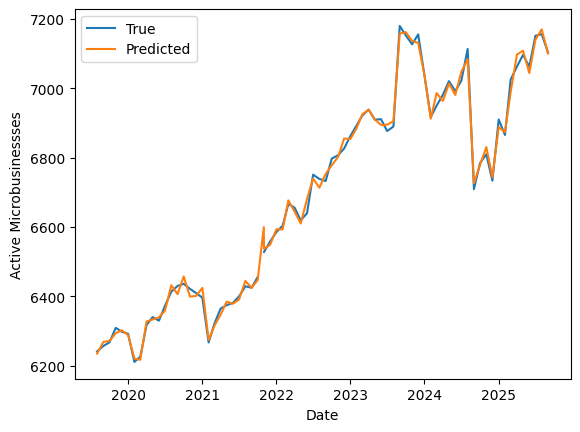

In [151]:
plt.plot(df_county_group.index.values, df_county_group['Microbusinesses'].values)
plt.plot(df_county_group.index.values, y_hat_prophet4.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

In [53]:
#Save the Prophet model with the engagement index as an independent variable
with open('active_microbusinesses_county_level_model.pkl', 'wb') as f:
    pickle.dump(proph4, f)

In [152]:
#Save the independent variable
np.save('engagement_index_county.npy', micro_county_prophet4['x1'])

### Forecast of Microbusiness Density

Prophet Approach with No Independent Variables

In [153]:
micro_county_prophet = pd.DataFrame(df_county_group['Microbusiness Density'])
micro_county_prophet.reset_index(inplace = True)
micro_county_prophet.rename(columns = {'Date':'ds', 'Microbusiness Density':'y'}, inplace = True)

proph = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

prophet_fit = proph.fit(micro_county_prophet)

18:48:17 - cmdstanpy - INFO - Chain [1] start processing


18:48:23 - cmdstanpy - INFO - Chain [1] done processing


In [154]:
y_hat_prophet = prophet_fit.predict(pd.DataFrame(micro_county_prophet['ds']))
y_hat_proph = y_hat_prophet[['ds', 'yhat']]
y_hat_prophet = y_hat_proph['yhat']
y_hat_prophet[y_hat_prophet < 0] = 0

mask = ~np.isnan(df_county_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet)

mse_prophet = mean_squared_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
rmse_prophet = mse_prophet**(1/2)
mae_prophet = mean_absolute_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
mape_prophet = mean_absolute_percentage_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
r2_prophet = r2_score(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
[mse_prophet, rmse_prophet, mae_prophet, mape_prophet, r2_prophet]

[0.0002364692155161894,
 0.01537755557675502,
 0.011914001960600912,
 0.003016123772332087,
 0.9932300053910885]

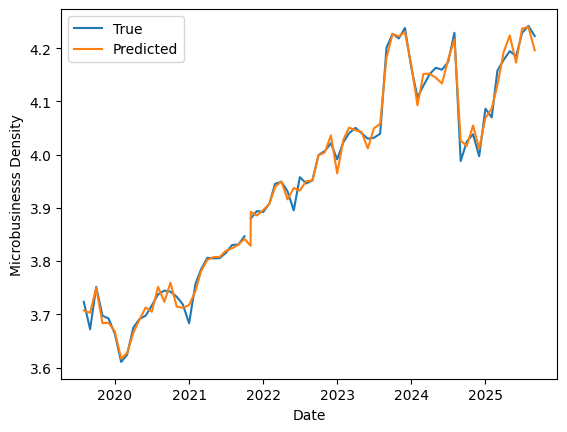

In [155]:
plt.plot(df_county_group.index.values, df_county_group['Microbusiness Density'].values)
plt.plot(df_county_group.index.values, y_hat_prophet.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with MAI as an Independent Variable

In [156]:
micro_county_prophet2 = df_county_group[['Microbusiness Density', 'wgtIndex_even']]
micro_county_prophet2.reset_index(inplace = True)
micro_county_prophet2.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even':'x1'}, inplace = True)

micro_county_prophet2['x1'] = micro_county_prophet2['x1'].fillna(micro_county_prophet2['x1'].median())

proph2 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph2.add_regressor('x1')
prophet_fit2 = proph2.fit(micro_county_prophet2)

18:48:27 - cmdstanpy - INFO - Chain [1] start processing


18:48:34 - cmdstanpy - INFO - Chain [1] done processing


In [157]:
y_hat_prophet2 = prophet_fit2.predict(pd.DataFrame(micro_county_prophet2[['ds', 'x1']]))
y_hat_proph2 = y_hat_prophet2[['ds', 'yhat']]
y_hat_prophet2 = y_hat_proph2['yhat']
y_hat_prophet2[y_hat_prophet2 < 0] = 0

mask = ~np.isnan(df_county_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet2)

mse_prophet2 = mean_squared_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
rmse_prophet2 = mse_prophet2**(1/2)
mae_prophet2 = mean_absolute_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
mape_prophet2 = mean_absolute_percentage_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
r2_prophet2 = r2_score(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
[mse_prophet2, rmse_prophet2, mae_prophet2, mape_prophet2, r2_prophet2]

[0.00020584093752504284,
 0.014347157820454991,
 0.011105876289616928,
 0.002817107912941685,
 0.9941068775726436]

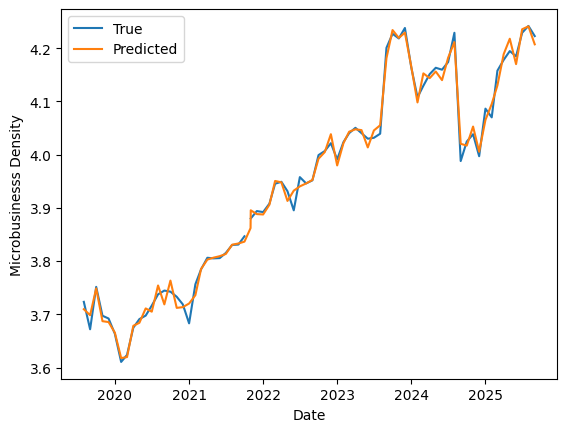

In [158]:
plt.plot(df_county_group.index.values, df_county_group['Microbusiness Density'].values)
plt.plot(df_county_group.index.values, y_hat_prophet2.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Infrastructure Index as an Independent Variable

In [159]:
micro_county_prophet3 = df_county_group[['Microbusiness Density', 'wgtIndex_even_infrastructure']]
micro_county_prophet3.reset_index(inplace = True)
micro_county_prophet3.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even_infrastructure':'x1'}, inplace = True)

micro_county_prophet3['x1'] = micro_county_prophet3['x1'].fillna(micro_county_prophet3['x1'].median())

proph3 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph3.add_regressor('x1')
prophet_fit3 = proph3.fit(micro_county_prophet3)

18:48:40 - cmdstanpy - INFO - Chain [1] start processing


18:48:47 - cmdstanpy - INFO - Chain [1] done processing


In [160]:
y_hat_prophet3 = prophet_fit3.predict(pd.DataFrame(micro_county_prophet3[['ds', 'x1']]))
y_hat_proph3 = y_hat_prophet3[['ds', 'yhat']]
y_hat_prophet3 = y_hat_proph3['yhat']
y_hat_prophet3[y_hat_prophet3 < 0] = 0

mask = ~np.isnan(df_county_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet3)

mse_prophet3 = mean_squared_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
rmse_prophet3 = mse_prophet3**(1/2)
mae_prophet3 = mean_absolute_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
mape_prophet3 = mean_absolute_percentage_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
r2_prophet3 = r2_score(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
[mse_prophet3, rmse_prophet3, mae_prophet3, mape_prophet3, r2_prophet3]

[0.0002299882858278109,
 0.015165364678365333,
 0.011645570824497414,
 0.0029501511795840475,
 0.9934155511457665]

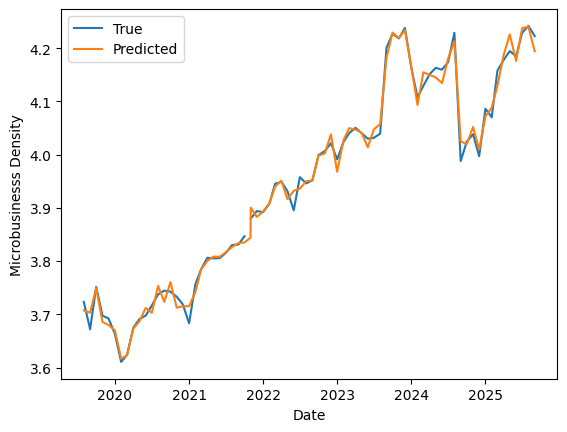

In [161]:
plt.plot(df_county_group.index.values, df_county_group['Microbusiness Density'].values)
plt.plot(df_county_group.index.values, y_hat_prophet3.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Engagement Index as an Independent Variable

In [162]:
micro_county_prophet4 = df_county_group[['Microbusiness Density', 'wgtIndex_even_engagement']]
micro_county_prophet4.reset_index(inplace = True)
micro_county_prophet4.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even_engagement':'x1'}, inplace = True)

micro_county_prophet4['x1'] = micro_county_prophet4['x1'].fillna(micro_county_prophet4['x1'].median())

proph4 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph4.add_regressor('x1')
prophet_fit4 = proph4.fit(micro_county_prophet4)

18:48:48 - cmdstanpy - INFO - Chain [1] start processing


18:48:55 - cmdstanpy - INFO - Chain [1] done processing


In [163]:
y_hat_prophet4 = prophet_fit4.predict(pd.DataFrame(micro_county_prophet4[['ds', 'x1']]))
y_hat_proph4 = y_hat_prophet4[['ds', 'yhat']]
y_hat_prophet4 = y_hat_proph4['yhat']
y_hat_prophet4[y_hat_prophet4 < 0] = 0

mask = ~np.isnan(df_county_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet4)

mse_prophet4 = mean_squared_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
rmse_prophet4 = mse_prophet4**(1/2)
mae_prophet4 = mean_absolute_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
mape_prophet4 = mean_absolute_percentage_error(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
r2_prophet4 = r2_score(df_county_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
[mse_prophet4, rmse_prophet4, mae_prophet4, mape_prophet4, r2_prophet4]

[0.0001723211002689121,
 0.013127113173463238,
 0.010225126368143883,
 0.002592662226749968,
 0.9950665336404334]

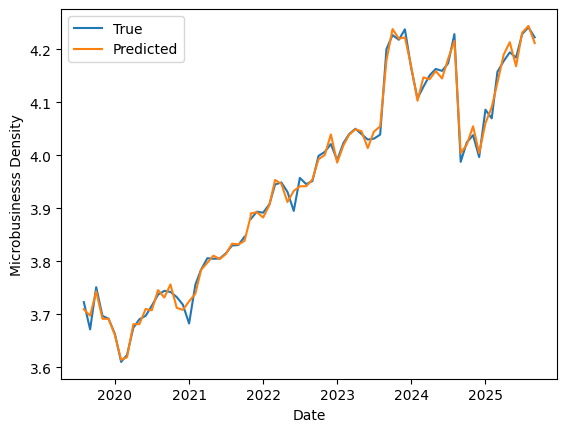

In [164]:
plt.plot(df_county_group.index.values, df_county_group['Microbusiness Density'].values)
plt.plot(df_county_group.index.values, y_hat_prophet4.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

In [66]:
#Save the Prophet model with the engagement index as an independent variable
with open('microbusiness_density_county_level_model.pkl', 'wb') as f:
    pickle.dump(proph4, f)

In [165]:
#Save the independent variable
np.save('engagement_index_county.npy', micro_county_prophet4['x1'])

## Microbusiness Forecasts at the City Level

In [166]:
df_city.head()

,cbsa_x,city_name,micro_metro,Date,Microbusinesses,Microbusiness Density,cbsa_y,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,49820.0,"Zapata, TX",Micropolitan Statistical Area,2019-08-01,35.0,0.367107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,46900.0,"Vernon, TX",Micropolitan Statistical Area,2019-08-01,104.0,1.040520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22620.0,"Forrest City, AR",Micropolitan Statistical Area,2019-08-01,124.0,0.604259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25820.0,"Hereford, TX",Micropolitan Statistical Area,2019-08-01,123.0,0.948854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29500.0,"Lamesa, TX",Micropolitan Statistical Area,2019-08-01,176.0,1.795918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [167]:
df_city_group = df_city[['Date', 'Microbusinesses', 'Microbusiness Density', 'wgtIndex_even', 'wgtIndex_even_engagement', 
                           'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].groupby(['Date']).mean()

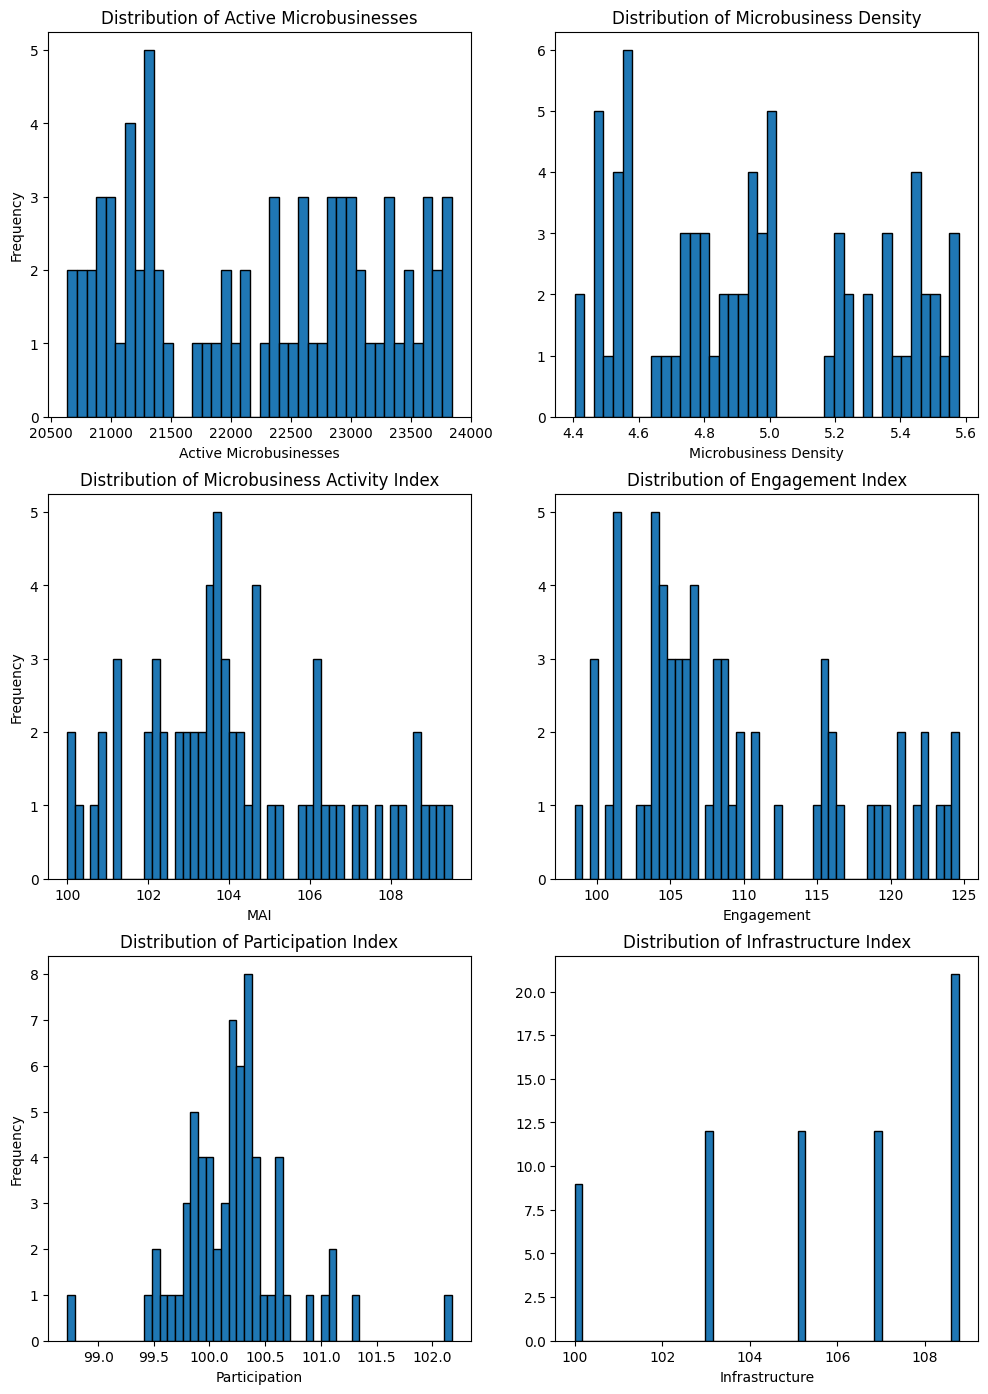

In [168]:
#Histogram of the average of microbusinesses and microbusiness density across cities
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 17))

ax[0, 0].hist(df_city_group['Microbusinesses'], bins = 40, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Active Microbusinesses');
ax[0, 0].set_xlabel('Active Microbusinesses');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_city_group['Microbusiness Density'], bins = 40, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Microbusiness Density');
ax[0, 1].set_xlabel('Microbusiness Density');

ax[1, 0].hist(df_city_group['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Microbusiness Activity Index');
ax[1, 0].set_xlabel('MAI');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_city_group['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Engagement Index');
ax[1, 1].set_xlabel('Engagement');

ax[2, 0].hist(df_city_group['wgtIndex_even_participation'], bins = 50, edgecolor = 'black');
ax[2, 0].set_title('Distribution of Participation Index');
ax[2, 0].set_xlabel('Participation');
ax[2, 0].set_ylabel('Frequency');

ax[2, 1].hist(df_city_group['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[2, 1].set_title('Distribution of Infrastructure Index');
ax[2, 1].set_xlabel('Infrastructure');

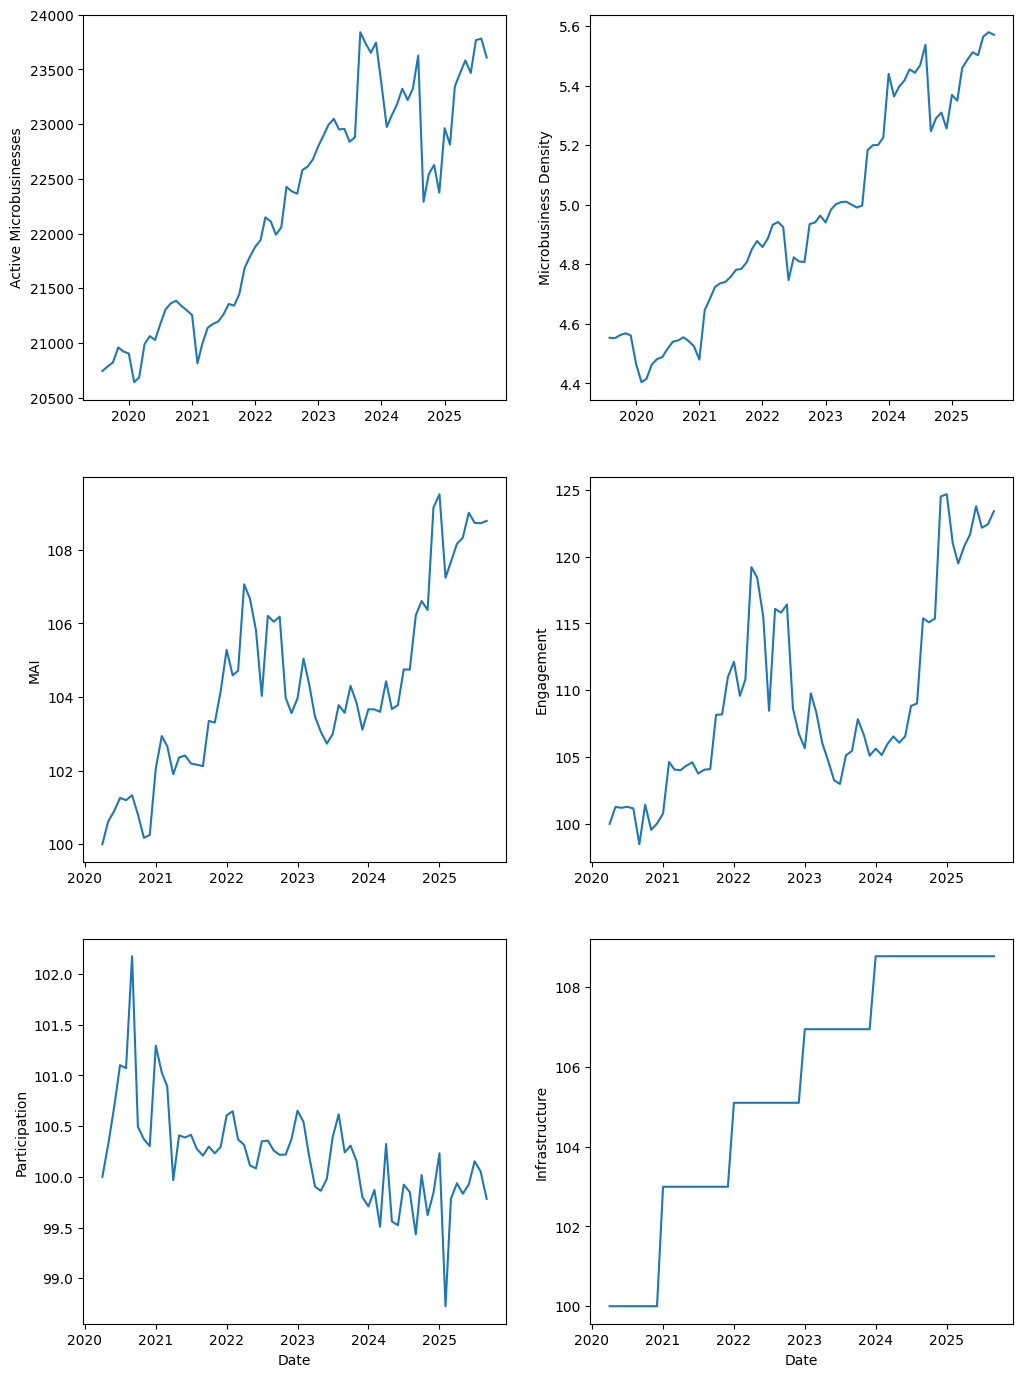

In [169]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12, 17))

df_micro = df_city_group.copy()
monthly_data = df_micro.resample('MS').sum()

ax[0, 0].plot(monthly_data.index.values, monthly_data['Microbusinesses'].values)
#ax[0, 0].set_title('Microbusiness Activity & Density Over Time');
ax[0, 0].set_ylabel('Active Microbusinesses');

ax[0, 1].plot(monthly_data.index.values, monthly_data['Microbusiness Density'].values)
#ax[0, 1].set_xlabel('Date');
ax[0, 1].set_ylabel('Microbusiness Density');

ax[1, 0].plot(monthly_data.index[monthly_data['wgtIndex_even'] > 0].values, 
              monthly_data['wgtIndex_even'][monthly_data['wgtIndex_even'] > 0].values)
ax[1, 0].set_ylabel('MAI');

ax[1, 1].plot(monthly_data[monthly_data['wgtIndex_even_engagement'] > 0].index.values, 
              monthly_data['wgtIndex_even_engagement'][monthly_data['wgtIndex_even_engagement'] > 0].values)
ax[1, 1].set_ylabel('Engagement');

ax[2, 0].plot(monthly_data.index[monthly_data['wgtIndex_even_participation'] > 0].values, 
              monthly_data['wgtIndex_even_participation'][monthly_data['wgtIndex_even_participation'] > 0].values)
ax[2, 0].set_xlabel('Date');
ax[2, 0].set_ylabel('Participation');

ax[2, 1].plot(monthly_data.index[monthly_data['wgtIndex_even_infrastructure'] > 0].values, 
              monthly_data['wgtIndex_even_infrastructure'][monthly_data['wgtIndex_even_infrastructure'] > 0].values)
ax[2, 1].set_xlabel('Date');
ax[2, 1].set_ylabel('Infrastructure');

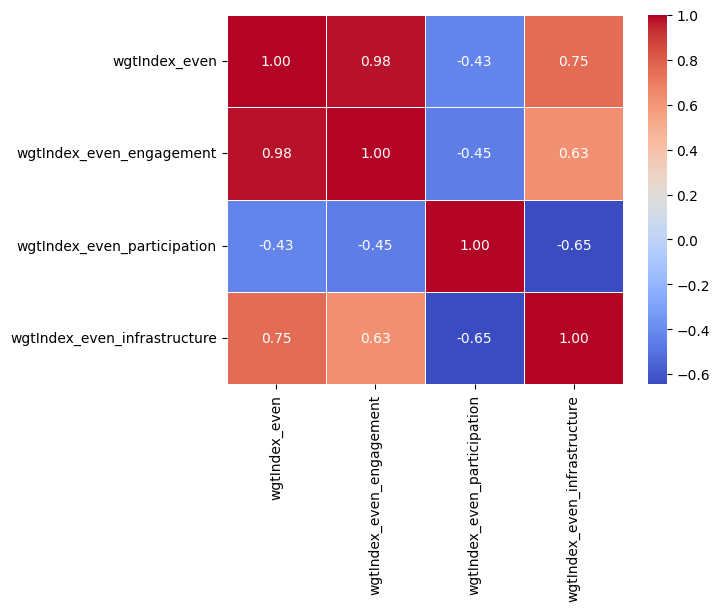

In [170]:
sns.heatmap(data = df_city_group[['wgtIndex_even', 'wgtIndex_even_engagement', 'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].corr(), 
            annot = True, fmt = '.2f', linewidths=.5, cmap = "coolwarm");

### Forecast of Active Microbusinesses

Prophet Approach with No Independent Variables

In [171]:
micro_city_prophet = pd.DataFrame(df_city_group['Microbusinesses'])
micro_city_prophet.reset_index(inplace = True)
micro_city_prophet.rename(columns = {'Date':'ds', 'Microbusinesses':'y'}, inplace = True)

proph = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

prophet_fit = proph.fit(micro_city_prophet)

18:50:29 - cmdstanpy - INFO - Chain [1] start processing
18:50:34 - cmdstanpy - INFO - Chain [1] done processing


In [172]:
y_hat_prophet = prophet_fit.predict(pd.DataFrame(micro_city_prophet['ds']))
y_hat_proph = y_hat_prophet[['ds', 'yhat']]
y_hat_prophet = y_hat_proph['yhat']
y_hat_prophet[y_hat_prophet < 0] = 0

mask = ~np.isnan(df_city_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet)

mse_prophet = mean_squared_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
rmse_prophet = mse_prophet**(1/2)
mae_prophet = mean_absolute_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
mape_prophet = mean_absolute_percentage_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
r2_prophet = r2_score(df_city_group['Microbusinesses'][mask.values], y_hat_prophet[mask.values])
[mse_prophet, rmse_prophet, mae_prophet, mape_prophet, r2_prophet]

[5714.876108668247,
 75.59679959276217,
 60.11808792523595,
 0.0026936085051368383,
 0.994281928807052]

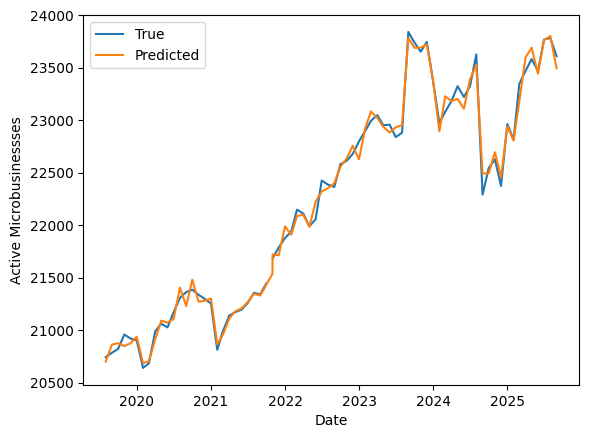

In [173]:
plt.plot(df_city_group.index.values, df_city_group['Microbusinesses'].values)
plt.plot(df_city_group.index.values, y_hat_prophet.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with MAI as an Independent Variable

In [174]:
micro_city_prophet2 = df_city_group[['Microbusinesses', 'wgtIndex_even']]
micro_city_prophet2.reset_index(inplace = True)
micro_city_prophet2.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even':'x1'}, inplace = True)

micro_city_prophet2['x1'] = micro_city_prophet2['x1'].fillna(micro_city_prophet2['x1'].median())

proph2 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph2.add_regressor('x1')
prophet_fit2 = proph2.fit(micro_city_prophet2)

18:50:40 - cmdstanpy - INFO - Chain [1] start processing
18:50:47 - cmdstanpy - INFO - Chain [1] done processing


In [175]:
y_hat_prophet2 = prophet_fit2.predict(pd.DataFrame(micro_city_prophet2[['ds', 'x1']]))
y_hat_proph2 = y_hat_prophet2[['ds', 'yhat']]
y_hat_prophet2 = y_hat_proph2['yhat']
y_hat_prophet2[y_hat_prophet2 < 0] = 0

mask = ~np.isnan(df_city_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet2)

mse_prophet2 = mean_squared_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
rmse_prophet2 = mse_prophet2**(1/2)
mae_prophet2 = mean_absolute_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
mape_prophet2 = mean_absolute_percentage_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
r2_prophet2 = r2_score(df_city_group['Microbusinesses'][mask.values], y_hat_prophet2[mask.values])
[mse_prophet2, rmse_prophet2, mae_prophet2, mape_prophet2, r2_prophet2]

[4044.537043291352,
 63.596674781716,
 50.18269984494666,
 0.0022488486840800933,
 0.9959532017289094]

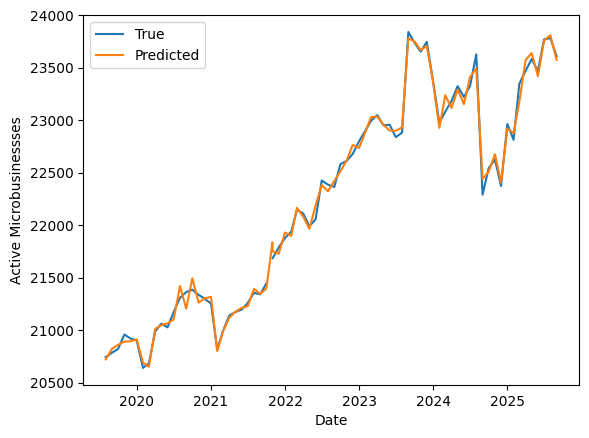

In [176]:
plt.plot(df_city_group.index.values, df_city_group['Microbusinesses'].values)
plt.plot(df_city_group.index.values, y_hat_prophet2.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Infrastructure Index as an Independent Variable

In [177]:
micro_city_prophet3 = df_city_group[['Microbusinesses', 'wgtIndex_even_infrastructure']]
micro_city_prophet3.reset_index(inplace = True)
micro_city_prophet3.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even_infrastructure':'x1'}, inplace = True)

micro_city_prophet3['x1'] = micro_city_prophet3['x1'].fillna(micro_city_prophet3['x1'].median())

proph3 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph3.add_regressor('x1')
prophet_fit3 = proph3.fit(micro_city_prophet3)

18:50:48 - cmdstanpy - INFO - Chain [1] start processing


18:50:53 - cmdstanpy - INFO - Chain [1] done processing


In [178]:
y_hat_prophet3 = prophet_fit3.predict(pd.DataFrame(micro_city_prophet3[['ds', 'x1']]))
y_hat_proph3 = y_hat_prophet3[['ds', 'yhat']]
y_hat_prophet3 = y_hat_proph3['yhat']
y_hat_prophet3[y_hat_prophet3 < 0] = 0

mask = ~np.isnan(df_city_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet3)

mse_prophet3 = mean_squared_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
rmse_prophet3 = mse_prophet3**(1/2)
mae_prophet3 = mean_absolute_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
mape_prophet3 = mean_absolute_percentage_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
r2_prophet3 = r2_score(df_city_group['Microbusinesses'][mask.values], y_hat_prophet3[mask.values])
[mse_prophet3, rmse_prophet3, mae_prophet3, mape_prophet3, r2_prophet3]

[5463.093030999563,
 73.91273930114865,
 57.23218102456628,
 0.0025657210053859876,
 0.9945338526521036]

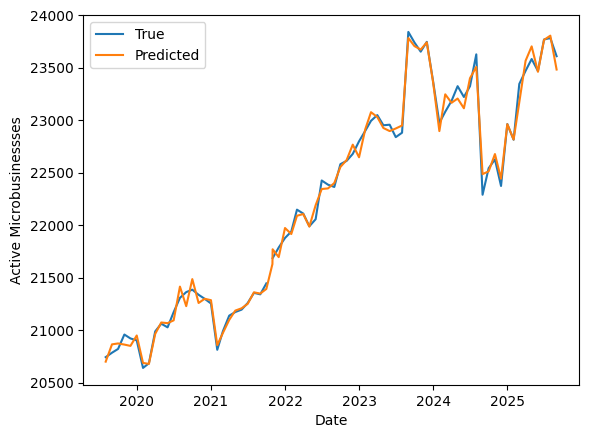

In [179]:
plt.plot(df_city_group.index.values, df_city_group['Microbusinesses'].values)
plt.plot(df_city_group.index.values, y_hat_prophet3.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Engagement Index as an Independent Variable

In [180]:
micro_city_prophet4 = df_city_group[['Microbusinesses', 'wgtIndex_even_engagement']]
micro_city_prophet4.reset_index(inplace = True)
micro_city_prophet4.rename(columns = {'Date':'ds', 'Microbusinesses':'y', 'wgtIndex_even_engagement':'x1'}, inplace = True)

micro_city_prophet4['x1'] = micro_city_prophet4['x1'].fillna(micro_city_prophet4['x1'].median())

proph4 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph4.add_regressor('x1')
prophet_fit4 = proph4.fit(micro_city_prophet4)

18:51:01 - cmdstanpy - INFO - Chain [1] start processing


18:51:06 - cmdstanpy - INFO - Chain [1] done processing


In [181]:
y_hat_prophet4 = prophet_fit4.predict(pd.DataFrame(micro_city_prophet4[['ds', 'x1']]))
y_hat_proph4 = y_hat_prophet4[['ds', 'yhat']]
y_hat_prophet4 = y_hat_proph4['yhat']
y_hat_prophet4[y_hat_prophet4 < 0] = 0

mask = ~np.isnan(df_city_group['Microbusinesses'].values) & ~np.isnan(y_hat_prophet4)

mse_prophet4 = mean_squared_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
rmse_prophet4 = mse_prophet4**(1/2)
mae_prophet4 = mean_absolute_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
mape_prophet4 = mean_absolute_percentage_error(df_city_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
r2_prophet4 = r2_score(df_city_group['Microbusinesses'][mask.values], y_hat_prophet4[mask.values])
[mse_prophet4, rmse_prophet4, mae_prophet4, mape_prophet4, r2_prophet4]

[3035.5031549504647,
 55.095400488157495,
 45.67414523235508,
 0.0020431406142234565,
 0.9969627997499197]

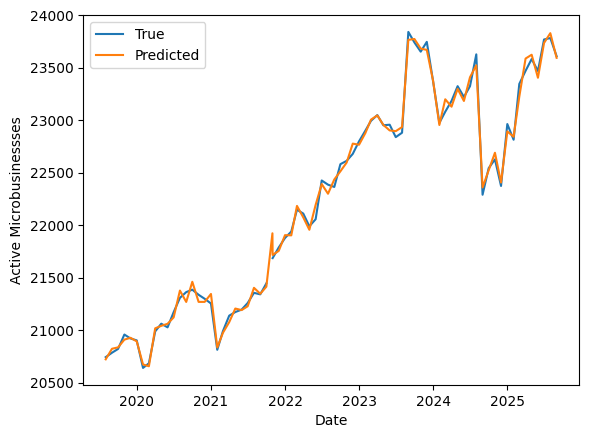

In [182]:
plt.plot(df_city_group.index.values, df_city_group['Microbusinesses'].values)
plt.plot(df_city_group.index.values, y_hat_prophet4.values);
plt.xlabel('Date')
plt.ylabel('Active Microbusinessses')
plt.legend(['True', 'Predicted']);

In [84]:
#Save the Prophet model with the engagement index as an independent variable
with open('active_microbusinesses_city_level_model.pkl', 'wb') as f:
    pickle.dump(proph4, f)

In [183]:
#Save the independent variable
np.save('engagement_index_city.npy', micro_city_prophet4['x1'])

### Forecast of Microbusiness Density

Prophet Approach with No Independent Variables

In [184]:
micro_city_prophet = pd.DataFrame(df_city_group['Microbusiness Density'])
micro_city_prophet.reset_index(inplace = True)
micro_city_prophet.rename(columns = {'Date':'ds', 'Microbusiness Density':'y'}, inplace = True)

proph = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

prophet_fit = proph.fit(micro_city_prophet)

18:51:37 - cmdstanpy - INFO - Chain [1] start processing
18:51:44 - cmdstanpy - INFO - Chain [1] done processing


In [185]:
y_hat_prophet = prophet_fit.predict(pd.DataFrame(micro_city_prophet['ds']))
y_hat_proph = y_hat_prophet[['ds', 'yhat']]
y_hat_prophet = y_hat_proph['yhat']
y_hat_prophet[y_hat_prophet < 0] = 0

mask = ~np.isnan(df_city_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet)

mse_prophet = mean_squared_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
rmse_prophet = mse_prophet**(1/2)
mae_prophet = mean_absolute_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
mape_prophet = mean_absolute_percentage_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
r2_prophet = r2_score(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet[mask.values])
[mse_prophet, rmse_prophet, mae_prophet, mape_prophet, r2_prophet]

[0.0006012447525669864,
 0.02452029266886891,
 0.019639376367287645,
 0.003983994472382682,
 0.9952305299148544]

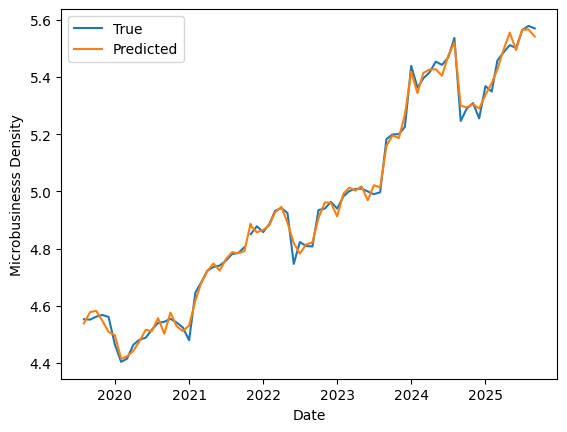

In [186]:
plt.plot(df_city_group.index.values, df_city_group['Microbusiness Density'].values)
plt.plot(df_city_group.index.values, y_hat_prophet.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with MAI as an Independent Variable

In [187]:
micro_city_prophet2 = df_city_group[['Microbusiness Density', 'wgtIndex_even']]
micro_city_prophet2.reset_index(inplace = True)
micro_city_prophet2.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even':'x1'}, inplace = True)

micro_city_prophet2['x1'] = micro_city_prophet2['x1'].fillna(micro_city_prophet2['x1'].median())

proph2 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph2.add_regressor('x1')
prophet_fit2 = proph2.fit(micro_city_prophet2)

18:51:48 - cmdstanpy - INFO - Chain [1] start processing
18:51:55 - cmdstanpy - INFO - Chain [1] done processing


In [188]:
y_hat_prophet2 = prophet_fit2.predict(pd.DataFrame(micro_city_prophet2[['ds', 'x1']]))
y_hat_proph2 = y_hat_prophet2[['ds', 'yhat']]
y_hat_prophet2 = y_hat_proph2['yhat']
y_hat_prophet2[y_hat_prophet2 < 0] = 0

mask = ~np.isnan(df_city_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet2)

mse_prophet2 = mean_squared_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
rmse_prophet2 = mse_prophet2**(1/2)
mae_prophet2 = mean_absolute_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
mape_prophet2 = mean_absolute_percentage_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
r2_prophet2 = r2_score(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet2[mask.values])
[mse_prophet2, rmse_prophet2, mae_prophet2, mape_prophet2, r2_prophet2]

[0.0005434343552310172,
 0.023311678515950267,
 0.018177321384829692,
 0.003690016676423959,
 0.9956891201304481]

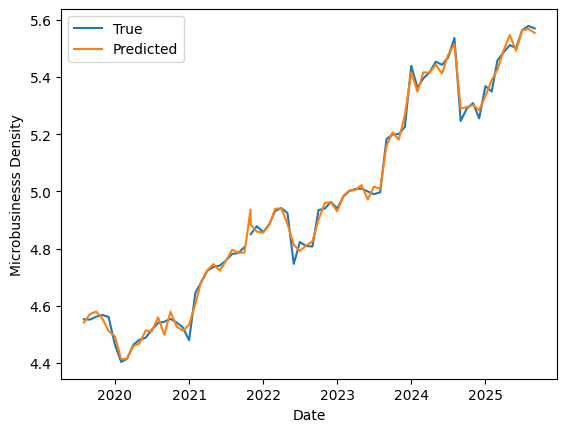

In [189]:
plt.plot(df_city_group.index.values, df_city_group['Microbusiness Density'].values)
plt.plot(df_city_group.index.values, y_hat_prophet2.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Infrastructure Index as an Independent Variable

In [190]:
micro_city_prophet3 = df_city_group[['Microbusiness Density', 'wgtIndex_even_infrastructure']]
micro_city_prophet3.reset_index(inplace = True)
micro_city_prophet3.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even_infrastructure':'x1'}, inplace = True)

micro_city_prophet3['x1'] = micro_city_prophet3['x1'].fillna(micro_city_prophet3['x1'].median())

proph3 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph3.add_regressor('x1')
prophet_fit3 = proph3.fit(micro_city_prophet3)

18:51:56 - cmdstanpy - INFO - Chain [1] start processing


18:52:02 - cmdstanpy - INFO - Chain [1] done processing


In [191]:
y_hat_prophet3 = prophet_fit3.predict(pd.DataFrame(micro_city_prophet3[['ds', 'x1']]))
y_hat_proph3 = y_hat_prophet3[['ds', 'yhat']]
y_hat_prophet3 = y_hat_proph3['yhat']
y_hat_prophet3[y_hat_prophet3 < 0] = 0

mask = ~np.isnan(df_city_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet3)

mse_prophet3 = mean_squared_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
rmse_prophet3 = mse_prophet3**(1/2)
mae_prophet3 = mean_absolute_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
mape_prophet3 = mean_absolute_percentage_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
r2_prophet3 = r2_score(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet3[mask.values])
[mse_prophet3, rmse_prophet3, mae_prophet3, mape_prophet3, r2_prophet3]

[0.000600730537532555,
 0.024509804926448414,
 0.019639312526723074,
 0.003983242166512618,
 0.995234609007792]

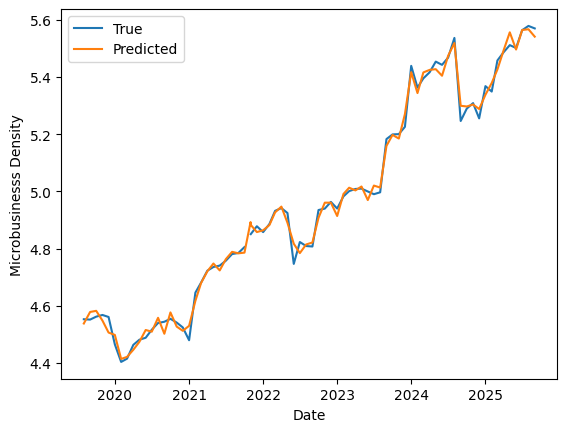

In [192]:
plt.plot(df_city_group.index.values, df_city_group['Microbusiness Density'].values)
plt.plot(df_city_group.index.values, y_hat_prophet3.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

Prophet Approach with the Engagement Index as an Independent Variable

In [193]:
micro_city_prophet4 = df_city_group[['Microbusiness Density', 'wgtIndex_even_engagement']]
micro_city_prophet4.reset_index(inplace = True)
micro_city_prophet4.rename(columns = {'Date':'ds', 'Microbusiness Density':'y', 'wgtIndex_even_engagement':'x1'}, inplace = True)

micro_city_prophet4['x1'] = micro_city_prophet4['x1'].fillna(micro_city_prophet4['x1'].median())

proph4 = Prophet(daily_seasonality = True, weekly_seasonality = True, yearly_seasonality = True, seasonality_mode = 'multiplicative')

proph4.add_regressor('x1')
prophet_fit4 = proph4.fit(micro_city_prophet4)

18:52:03 - cmdstanpy - INFO - Chain [1] start processing


18:52:10 - cmdstanpy - INFO - Chain [1] done processing


In [194]:
y_hat_prophet4 = prophet_fit4.predict(pd.DataFrame(micro_city_prophet4[['ds', 'x1']]))
y_hat_proph4 = y_hat_prophet4[['ds', 'yhat']]
y_hat_prophet4 = y_hat_proph4['yhat']
y_hat_prophet4[y_hat_prophet4 < 0] = 0

mask = ~np.isnan(df_city_group['Microbusiness Density'].values) & ~np.isnan(y_hat_prophet4)

mse_prophet4 = mean_squared_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
rmse_prophet4 = mse_prophet4**(1/2)
mae_prophet4 = mean_absolute_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
mape_prophet4 = mean_absolute_percentage_error(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
r2_prophet4 = r2_score(df_city_group['Microbusiness Density'][mask.values], y_hat_prophet4[mask.values])
[mse_prophet4, rmse_prophet4, mae_prophet4, mape_prophet4, r2_prophet4]

[0.0004628301553395128,
 0.02151348775395363,
 0.016708846597190363,
 0.003398703143839402,
 0.9963285258275095]

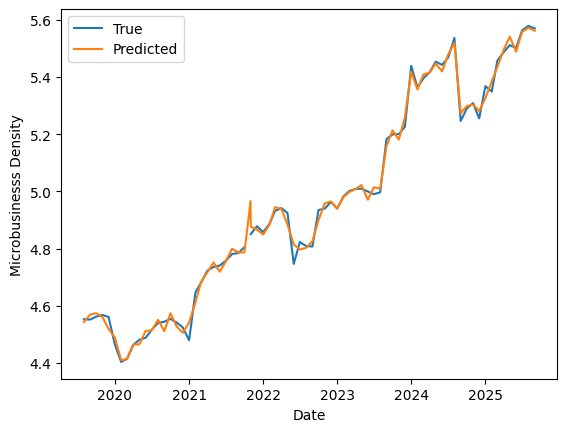

In [195]:
plt.plot(df_city_group.index.values, df_city_group['Microbusiness Density'].values)
plt.plot(df_city_group.index.values, y_hat_prophet4.values);
plt.xlabel('Date')
plt.ylabel('Microbusinesss Density')
plt.legend(['True', 'Predicted']);

In [97]:
#Save the Prophet model with the engagement index as an independent variable
with open('microbusiness_density_city_level_model.pkl', 'wb') as f:
    pickle.dump(proph4, f)

In [196]:
#Save the independent variable
np.save('engagement_index_city.npy', micro_city_prophet4['x1'])